# InfraBayesian vs Bayesian Agent Comparison

Compare the InfraBayesianAgent (non-KU, single a-measure, GaussianBelief) against the existing BayesianAgent across all environments.

**Expectation**: `GaussianBelief` replicates BayesianAgent's exact precision-weighted update math. With the IB plumbing being a no-op in non-KU mode (lambda=1, b=0), the two agents should produce **identical** results everywhere.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

from ibrl.simulators import simulate
from ibrl.utils import construct_environment
from ibrl.agents import BayesianAgent, InfraBayesianAgent
from ibrl.infrabayesian.beliefs import GaussianBelief

## Configuration

In [2]:
all_envs = [
    "bandit", "switching",
    "newcomb", "damascus", "asymmetric-damascus", "coordination", "pdbandit",
]

options = {
    "num_actions": 2,
    "num_steps":   500,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}

def make_agents():
    n = options["num_actions"]
    shared = dict(num_actions=n, seed=options["seed"] + 0x01234567, epsilon=0.1)
    return {
        "bayesian":    BayesianAgent(**shared),
        "ib-gaussian": InfraBayesianAgent(**shared, belief=GaussianBelief(num_actions=n)),
    }

## Run experiments

In [3]:
all_results = {}

for env_name in all_envs:
    all_results[env_name] = {}
    agents = make_agents()

    for agent_name, agent in agents.items():
        env = construct_environment(env_name, options)
        print(f"Running: {env_name} / {agent_name}")

        results = simulate(env, agent, options)
        all_results[env_name][agent_name] = results

        print(f"  optimal: {results['optimal_reward']:.4f}  "
              f"final avg: {results['average_reward'][0, -1]:.4f}")

print("\nDone.")

Running: bandit / bayesian
  optimal: 0.7278  final avg: 0.7500
Running: bandit / ib-gaussian
  optimal: 0.7278  final avg: 0.7500
Running: switching / bayesian
  optimal: 1.0000  final avg: 0.4500
Running: switching / ib-gaussian
  optimal: 1.0000  final avg: 0.4500
Running: newcomb / bayesian
  optimal: 1.0000  final avg: 0.6400
Running: newcomb / ib-gaussian
  optimal: 1.0000  final avg: 0.6400
Running: damascus / bayesian
  optimal: 0.5000  final avg: 0.0500
Running: damascus / ib-gaussian
  optimal: 0.5000  final avg: 0.0500
Running: asymmetric-damascus / bayesian
  optimal: 0.6667  final avg: 0.5500
Running: asymmetric-damascus / ib-gaussian
  optimal: 0.6667  final avg: 0.5500
Running: coordination / bayesian
  optimal: 2.0000  final avg: 1.1500
Running: coordination / ib-gaussian
  optimal: 2.0000  final avg: 1.1500
Running: pdbandit / bayesian
  optimal: 0.7760  final avg: 0.5041
Running: pdbandit / ib-gaussian
  optimal: 0.7760  final avg: 0.5041

Done.


## Cumulative regret comparison

One subplot per environment. All agents plotted together. On bandit/switching, the bayesian and ib-gaussian curves should overlap perfectly.

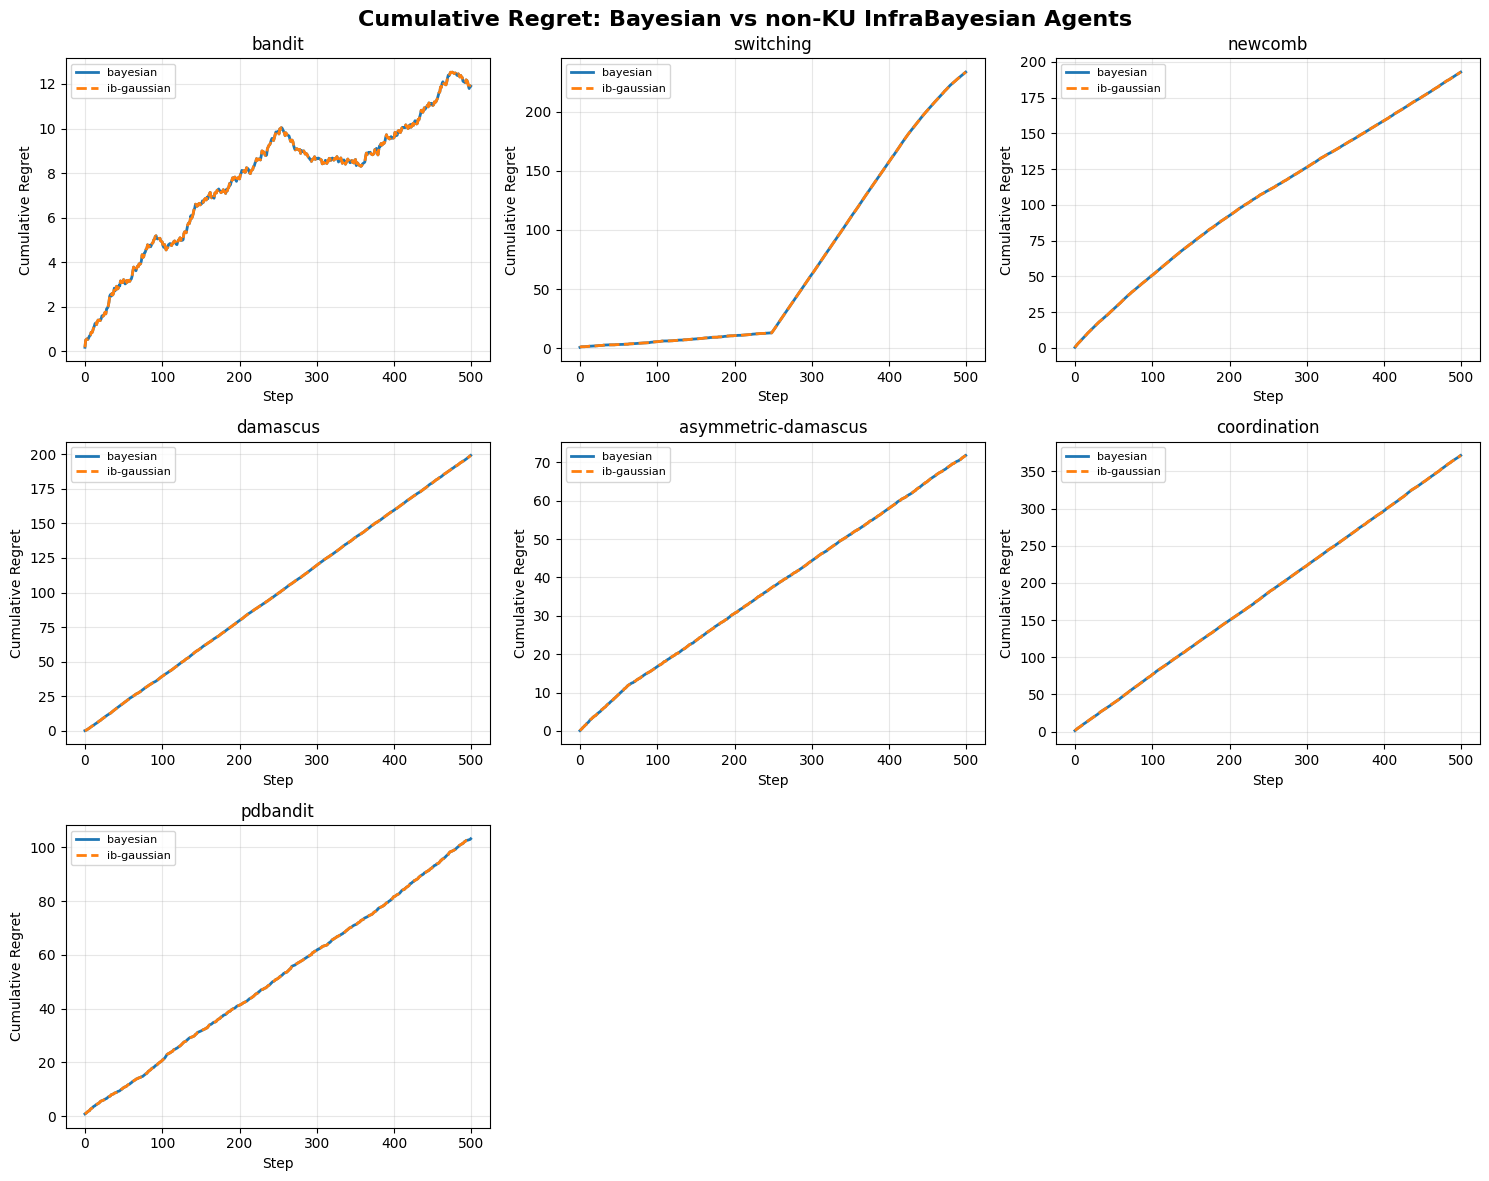

In [7]:
cols = 3
rows = math.ceil(len(all_envs) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, env_name in enumerate(all_envs):
    ax = axes[i]
    for agent_name, res in all_results[env_name].items():
        avg_reward = res["average_reward"][0, :]
        optimal = res["optimal_reward"]
        cumulative_regret = np.cumsum(optimal - avg_reward)
        if "ib-" in agent_name:
            ls="--"
        else:
            ls="-"
        ax.plot(cumulative_regret, label=agent_name, linewidth=2, ls=ls)
    ax.set_title(env_name)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(all_envs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Cumulative Regret: Bayesian vs non-KU InfraBayesian Agents", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Selection probabilities

Per-agent, per-environment view of how the policy evolves over time.

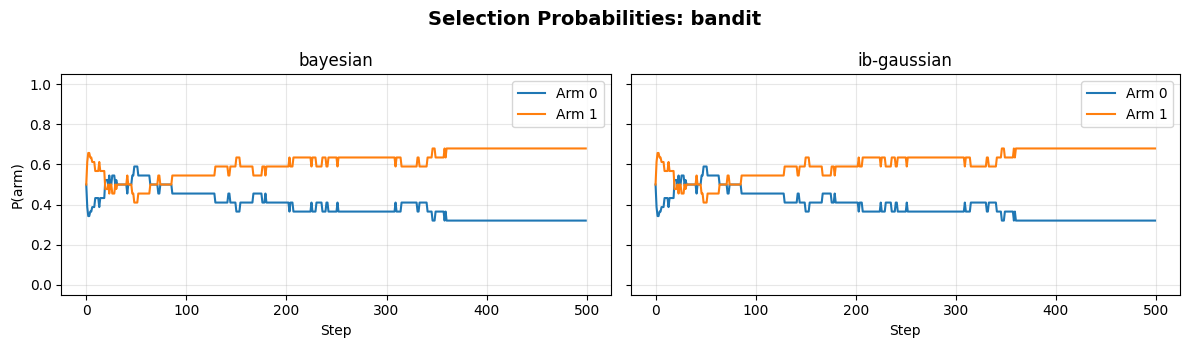

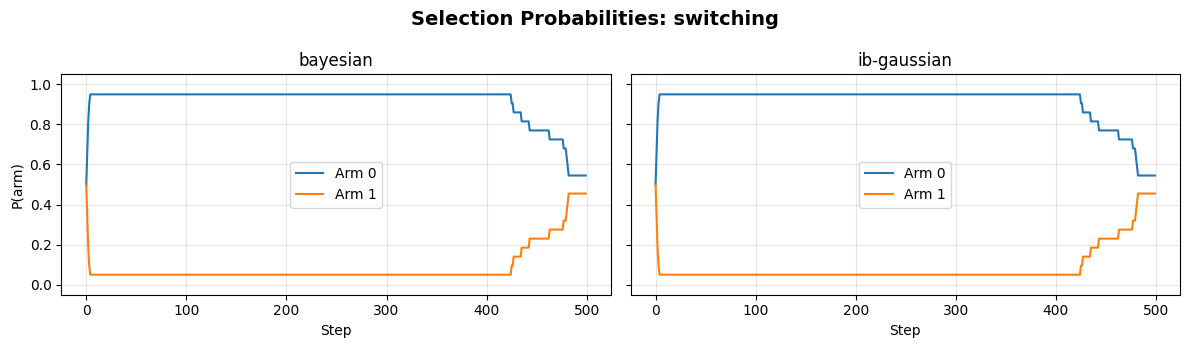

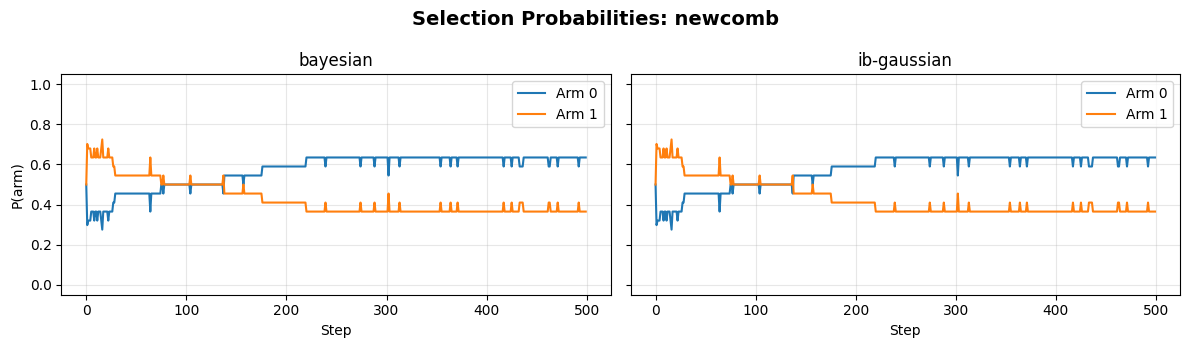

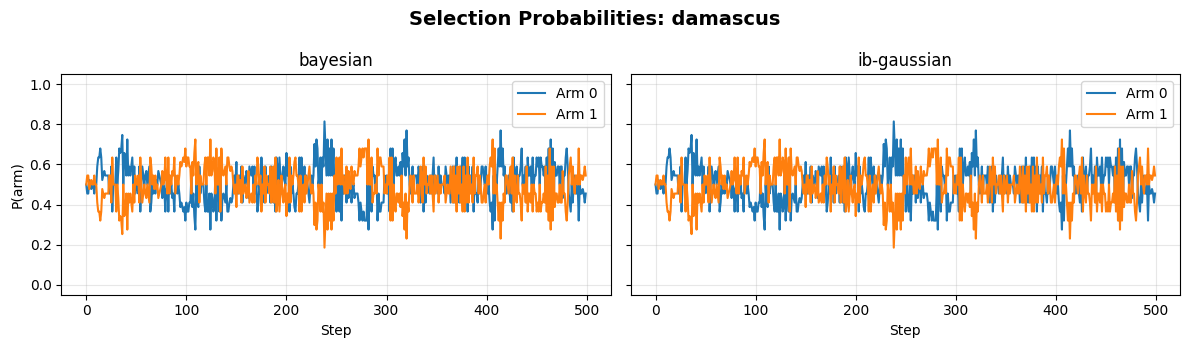

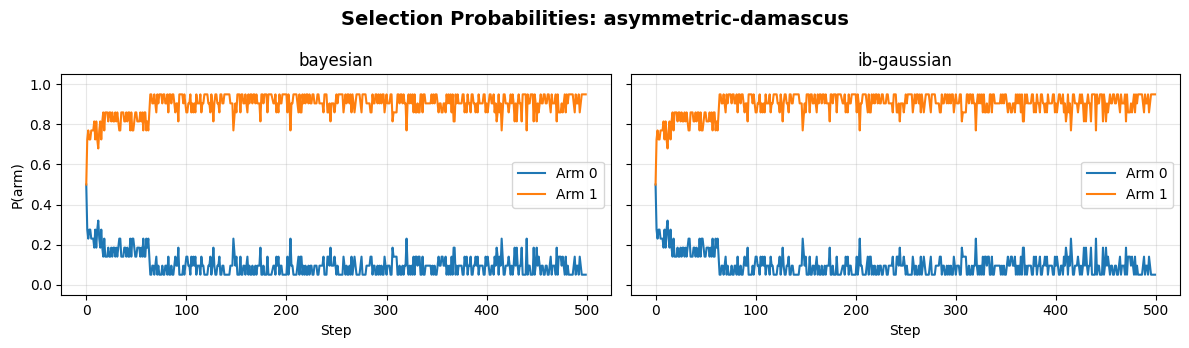

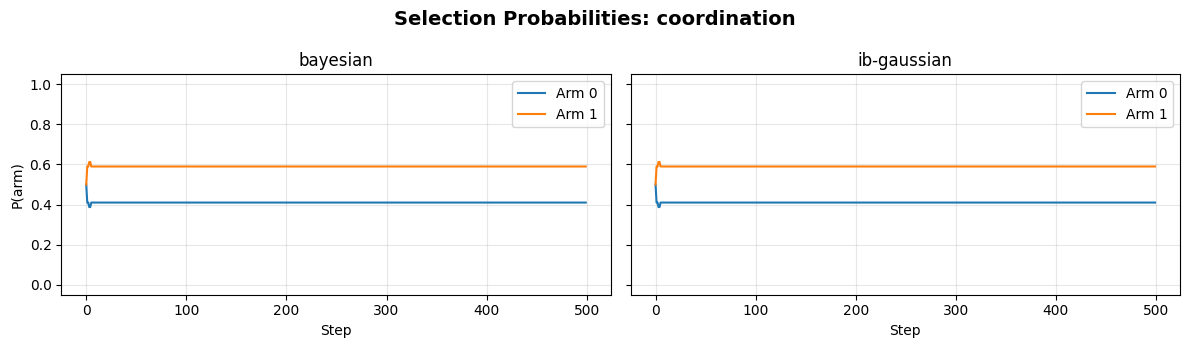

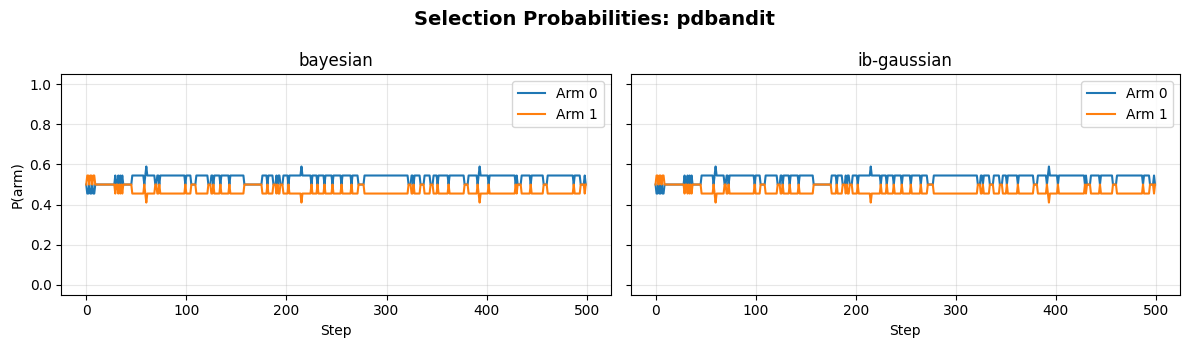

In [5]:
k = options["num_actions"]

for env_name in all_envs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
    fig.suptitle(f"Selection Probabilities: {env_name}", fontsize=14, fontweight="bold")

    for j, agent_name in enumerate(["bayesian", "ib-gaussian"]):
        ax = axes[j]
        res = all_results[env_name][agent_name]
        for arm in range(k):
            ax.plot(res["probabilities"][:, :, arm].mean(axis=0), label=f"Arm {arm}")
        ax.set_title(agent_name)
        ax.set_xlabel("Step")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.set_ylabel("P(arm)")
        ax.legend()

    plt.tight_layout()
    plt.show()

## Summary table

In [6]:
print(f"{'Environment':<25} {'Optimal':>8} {'Bayesian':>10} {'IB-Gauss':>10} {'Diff':>8}")
print("-" * 65)
for env_name in all_envs:
    optimal = all_results[env_name]["bayesian"]["optimal_reward"]
    bay = all_results[env_name]["bayesian"]["average_reward"][0, -50:].mean()
    ib = all_results[env_name]["ib-gaussian"]["average_reward"][0, -50:].mean()
    diff = ib - bay
    print(f"{env_name:<25} {optimal:>8.3f} {bay:>10.3f} {ib:>10.3f} {diff:>+8.4f}")

Environment                Optimal   Bayesian   IB-Gauss     Diff
-----------------------------------------------------------------
bandit                       0.728      0.712      0.712  +0.0000
switching                    1.000      0.346      0.346  +0.0000
newcomb                      1.000      0.654      0.654  +0.0000
damascus                     0.500      0.100      0.100  +0.0000
asymmetric-damascus          0.667      0.529      0.529  +0.0000
coordination                 2.000      1.257      1.257  +0.0000
pdbandit                     0.776      0.560      0.560  +0.0000
